<a href="https://colab.research.google.com/github/aryamokashi137/Greedy-RF-SoilMapper/blob/main/Greedy_RF_soilmapper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("Sakri_Soil_Fertility_Version_2.csv")

print(df.shape)
df.head()

(138192, 8)


,Latitude,Longitude,NDVI,EVI,SAVI,Soil_Moisture,Elevation,Fertility_Level
0,20.970047,74.320004,-0.143063,-0.001752,-0.099691,0.199856,407.0,Low
1,20.969778,74.320004,0.133883,0.000880,0.067731,0.393718,406.0,Low
2,20.969508,74.320004,0.303939,0.001488,0.125526,0.512757,407.0,Moderate
3,20.969239,74.320004,-0.015352,-0.000144,-0.009262,0.289254,408.0,Low
4,20.968969,74.320004,-0.091439,-0.001144,-0.061284,0.235993,408.0,Low


In [3]:
# Data cleaning
# Remove duplicates
df = df.drop_duplicates()

# Check missing values
print(df.isnull().sum())

# Fill if any missing
df = df.fillna(df.median(numeric_only=True))

Latitude           0
Longitude          0
NDVI               0
EVI                0
SAVI               0
Soil_Moisture      0
Elevation          0
Fertility_Level    0
dtype: int64


In [6]:
# Encode target
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Fertility_Label'] = le.fit_transform(df['Fertility_Level'])

class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Class Mapping:", class_mapping)

Class Mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Moderate': np.int64(2), 'Very High': np.int64(3)}


In [9]:
# train/test split
from sklearn.model_selection import train_test_split

features = ['NDVI','EVI','SAVI','Soil_Moisture','Elevation']

X = df[features]
y = df['Fertility_Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [10]:
# greedy forward feature selection
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

def greedy_selection(X, y):
    remaining = list(X.columns)
    selected = []
    best_score = 0

    while remaining:
        scores = []
        for feature in remaining:
            temp_features = selected + [feature]
            model = RandomForestClassifier(n_estimators=150, random_state=42)
            score = cross_val_score(model, X[temp_features], y, cv=5).mean()
            scores.append((score, feature))

        scores.sort(reverse=True)
        best_new_score, best_feature = scores[0]

        if best_new_score > best_score:
            selected.append(best_feature)
            remaining.remove(best_feature)
            best_score = best_new_score
            print(f"Added: {best_feature} | CV Score: {best_new_score}")
        else:
            break

    return selected

selected_features = greedy_selection(X_train, y_train)

print("Final Selected Features:", selected_features)

Added: Soil_Moisture | CV Score: 0.9999819090477283
Added: EVI | CV Score: 0.9999909543193125
Final Selected Features: ['Soil_Moisture', 'EVI']


In [11]:
# train optimized random forest
rf_opt = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_opt.fit(X_train[selected_features], y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [12]:
from sklearn.metrics import accuracy_score

# Class prediction
y_pred = rf_opt.predict(X_test[selected_features])

# Probability predictions
probabilities = rf_opt.predict_proba(X_test[selected_features])

# Confidence score = max probability (0 to 1)
fertility_confidence = probabilities.max(axis=1)

print("Optimized RF Accuracy:", accuracy_score(y_test, y_pred))

Optimized RF Accuracy: 0.9999638192409277


In [13]:
# Add to dataframe for analysis
results_df = X_test.copy()
results_df['True_Label'] = y_test.values
results_df['Predicted_Label'] = y_pred
results_df['Fertility_Confidence'] = fertility_confidence

results_df.head()

,NDVI,EVI,SAVI,Soil_Moisture,Elevation,True_Label,Predicted_Label,Fertility_Confidence
39788,-0.017708,-0.000172,-0.010669,0.287605,418.0,1,1,1.000000
20764,0.362914,0.001770,0.145045,0.554040,425.0,2,2,1.000000
120731,-0.141440,-0.001636,-0.093100,0.200992,504.0,1,1,1.000000
122278,0.597069,0.001685,0.176896,0.717948,537.0,0,0,0.993333
45000,0.270076,0.001066,0.101002,0.489053,417.0,2,2,1.000000


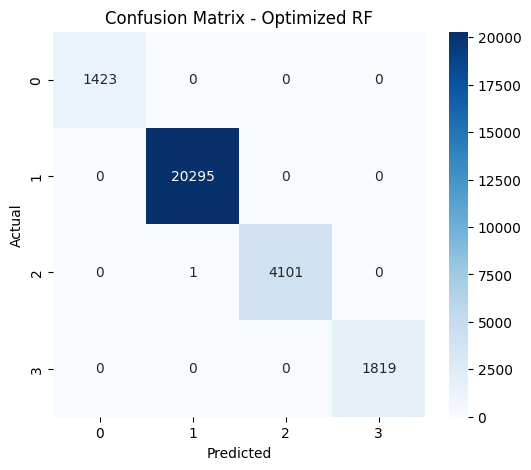

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1423
           1       1.00      1.00      1.00     20295
           2       1.00      1.00      1.00      4102
           3       1.00      1.00      1.00      1819

    accuracy                           1.00     27639
   macro avg       1.00      1.00      1.00     27639
weighted avg       1.00      1.00      1.00     27639



In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix - Optimized RF")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, y_pred))

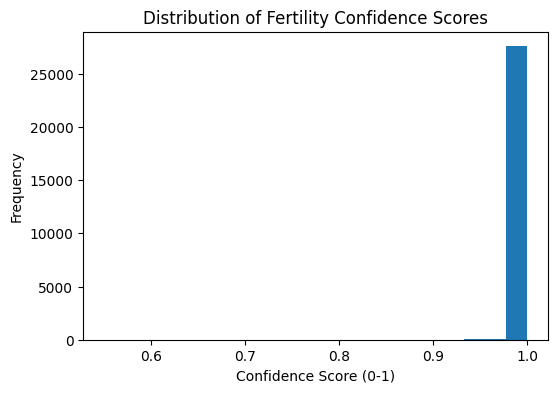

In [15]:
plt.figure(figsize=(6,4))
plt.hist(fertility_confidence, bins=20)
plt.title("Distribution of Fertility Confidence Scores")
plt.xlabel("Confidence Score (0-1)")
plt.ylabel("Frequency")
plt.show()

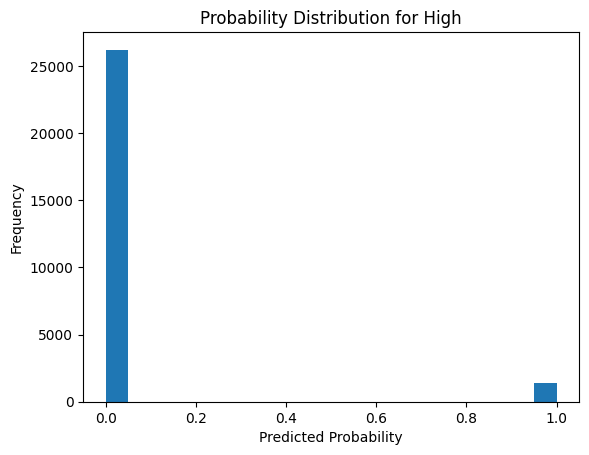

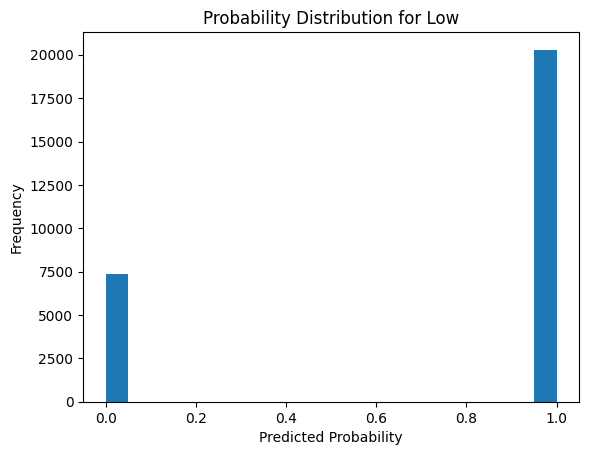

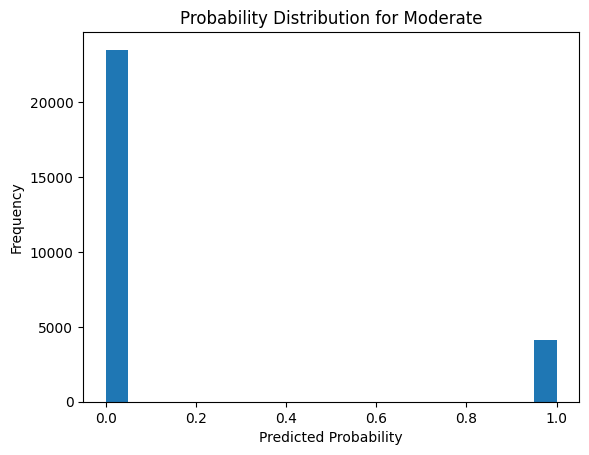

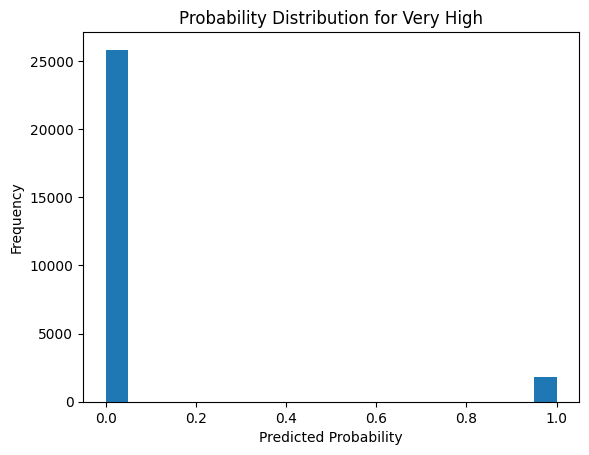

In [16]:
for i, class_name in enumerate(le.classes_):
    plt.figure()
    plt.hist(probabilities[:, i], bins=20)
    plt.title(f"Probability Distribution for {class_name}")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Frequency")
    plt.show()

In [19]:
noise_factor = 0.05
X_noisy = X + noise_factor * np.random.normal(size=X.shape)

X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_noisy, y, test_size=0.2, random_state=42, stratify=y)

rf_noise = RandomForestClassifier(n_estimators=300, random_state=42)
rf_noise.fit(X_train_n[selected_features], y_train_n)

noise_acc = accuracy_score(y_test_n, rf_noise.predict(X_test_n[selected_features]))

print("Accuracy without Noise:", accuracy_score(y_test, y_pred))
print("Accuracy with Noise:", noise_acc)
print("Performance Drop:", accuracy_score(y_test, y_pred) - noise_acc)

Accuracy without Noise: 0.9999638192409277
Accuracy with Noise: 0.8951119794493289
Performance Drop: 0.10485183979159884


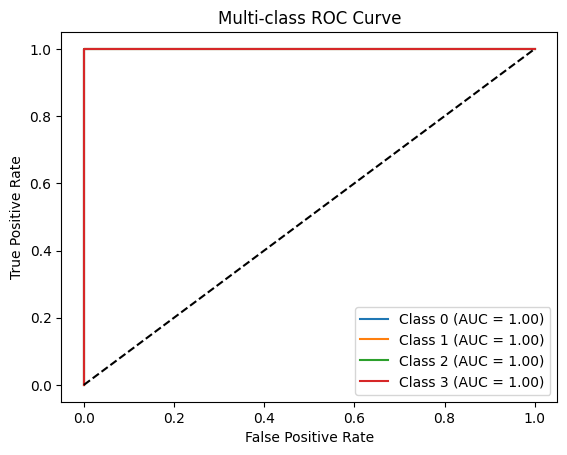

In [20]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Binarize labels
y_test_bin = label_binarize(y_test, classes=np.unique(y))
n_classes = y_test_bin.shape[1]

plt.figure()

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probabilities[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve")
plt.legend()
plt.show()

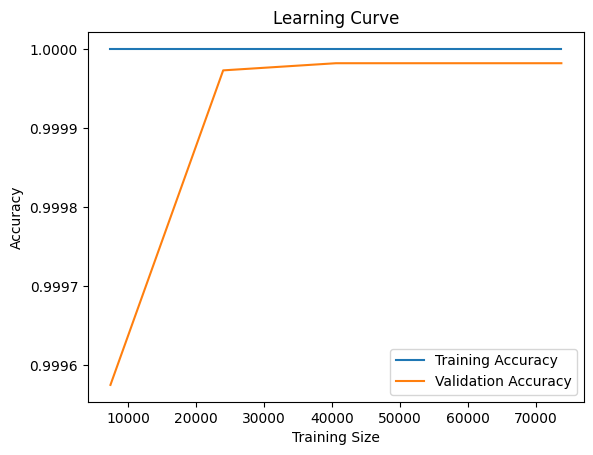

In [21]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    rf_opt,
    X_train[selected_features],
    y_train,
    cv=3,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.figure()
plt.plot(train_sizes, train_scores.mean(axis=1), label="Training Accuracy")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Validation Accuracy")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()